In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

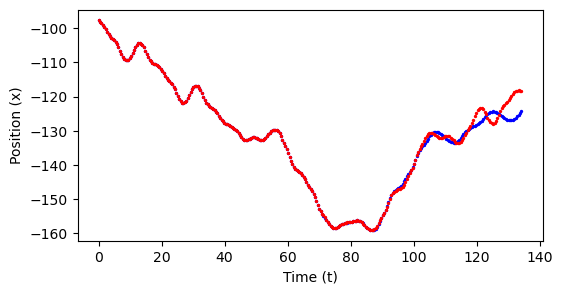

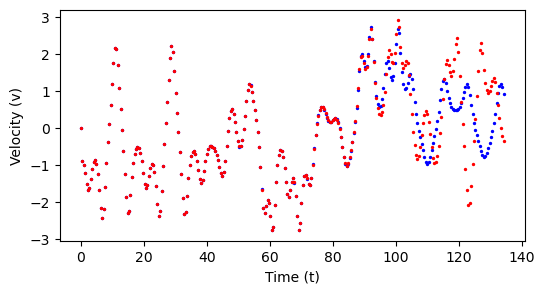

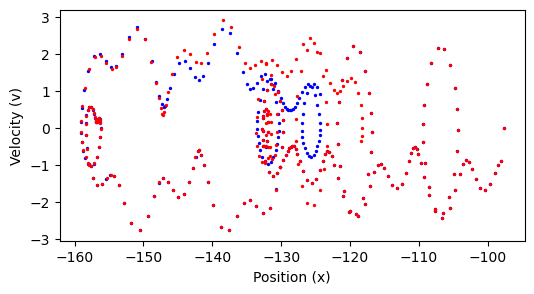

In [ ]:
real_data = pd.read_csv('dynamics_real.csv')
sim_data = pd.read_csv('dynamics_simulated.csv')

# cutting down data to some approchable interval so plots arent cluttered
interval = 300
real_t = real_data['t'].iloc[:interval]
real_x = real_data['x'].iloc[:interval]
real_v = real_data['v'].iloc[:interval]
sim_t = sim_data['t'].iloc[:interval]
sim_x = sim_data['x'].iloc[:interval]
sim_v = sim_data['v'].iloc[:interval]

plt.figure(figsize=(6, 3))
plt.scatter(real_t, real_x, s=2, label='Real Data', color='blue')
plt.scatter(sim_t, sim_x, s=2, label='Simulated Data', color='red')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.show()
# can see what the homework was talking about with stuff happening around t = 100

plt.figure(figsize=(6, 3))
plt.scatter(real_t, real_v, s=2, label='Real Data', color='blue')
plt.scatter(sim_t, sim_v, s=2, label='Simulated Data', color='red')
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.show()

plt.figure(figsize=(6, 3))
plt.scatter(real_x, real_v, s=2, label='Real Data', color='blue')
plt.scatter(sim_x, sim_v, s=2, label='Simulated Data', color='red')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.show()




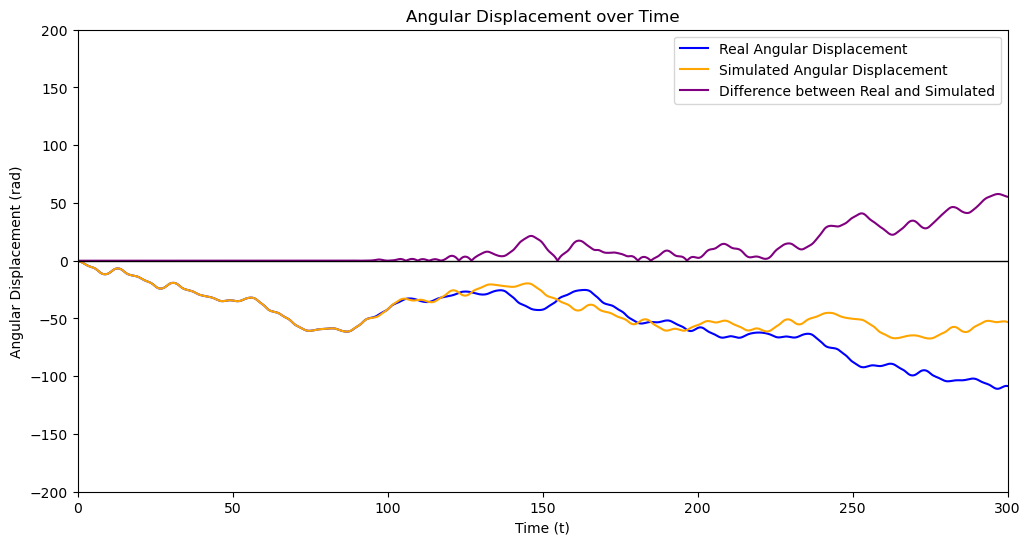

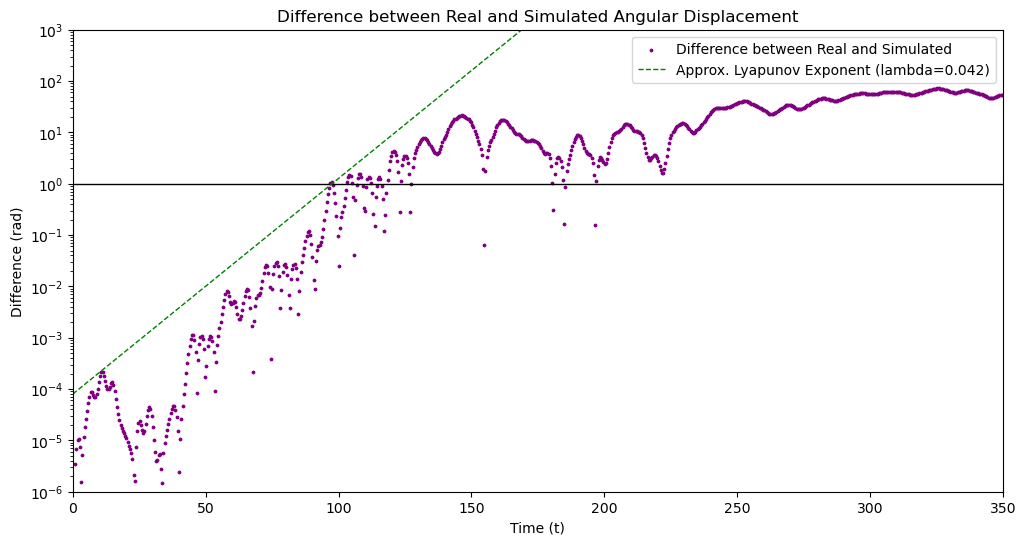

In [ ]:
# Angular displacement from x values (x is periodic in 2*pi)
def angular_displacement_from_x(x_series):
    x = np.asarray(x_series, dtype=float)
    x_unwrapped = np.unwrap(x)  # remove 2*pi jumps
    cumulative_disp = x_unwrapped - x_unwrapped[0]
    step_disp = np.diff(x_unwrapped)
    return x_unwrapped, cumulative_disp, step_disp

real_unwrapped, real_cum_disp, real_step_disp = angular_displacement_from_x(real_data['x'])
sim_unwrapped, sim_cum_disp, sim_step_disp = angular_displacement_from_x(sim_data['x'])

real_out = pd.DataFrame({
    't': real_data['t'],
    'x_raw': real_data['x'],
    'x_unwrapped': real_unwrapped,
    'cum_angular_displacement': real_cum_disp
})

sim_out = pd.DataFrame({
    't': sim_data['t'],
    'x_raw': sim_data['x'],
    'x_unwrapped': sim_unwrapped,
    'cum_angular_displacement': sim_cum_disp
})
# above code is from copilot, i was too lazy to figure it out myself

# absolute value of the differences in angular displacement
differences = abs(real_out['cum_angular_displacement'] - sim_out['cum_angular_displacement'])

plt.figure(figsize=(12, 6))
plt.plot(real_out['t'], real_out['cum_angular_displacement'], label='Real Angular Displacement', color='blue')
plt.plot(sim_out['t'], sim_out['cum_angular_displacement'], label='Simulated Angular Displacement', color='orange')
plt.plot(real_out['t'], differences, label='Difference between Real and Simulated', color='purple')
plt.axhline(0, color='black', linestyle='-', linewidth=1) # line at y=0 for reference
plt.axis([0, 300, -200, 200])  
plt.xlabel('Time (t)')
plt.ylabel('Angular Displacement (rad)')
plt.title('Angular Displacement over Time')
plt.legend()
plt.show()

# line values to approx. slope since that is the lyapunov exponent
slope = 0.042
intercept = 0.00008

plt.figure(figsize=(12, 6))
plt.scatter(real_out['t'], differences, s = 3 ,label='Difference between Real and Simulated', color='purple')
plt.axhline(0.9999, color='black', linestyle='-', linewidth=1)  # Add horizontal line at about y=0 for reference
plt.axline(xy1=(0, intercept), slope=slope, color='green', linestyle='--', linewidth=1, label=f'Approx. Lyapunov Exponent (lambda={slope})')
plt.axis([0, 350, 1e-6, 1000]) 
plt.yscale('log')  
plt.xlabel('Time (t)')
plt.ylabel('Difference (rad)')
plt.title('Difference between Real and Simulated Angular Displacement')
plt.legend()
plt.show()


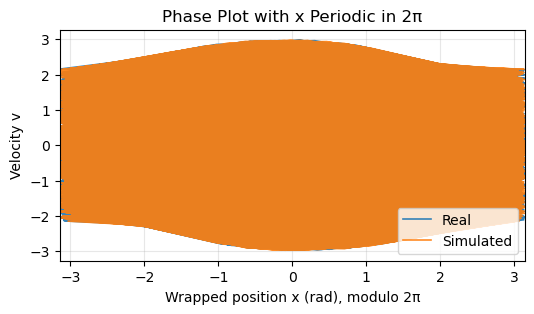

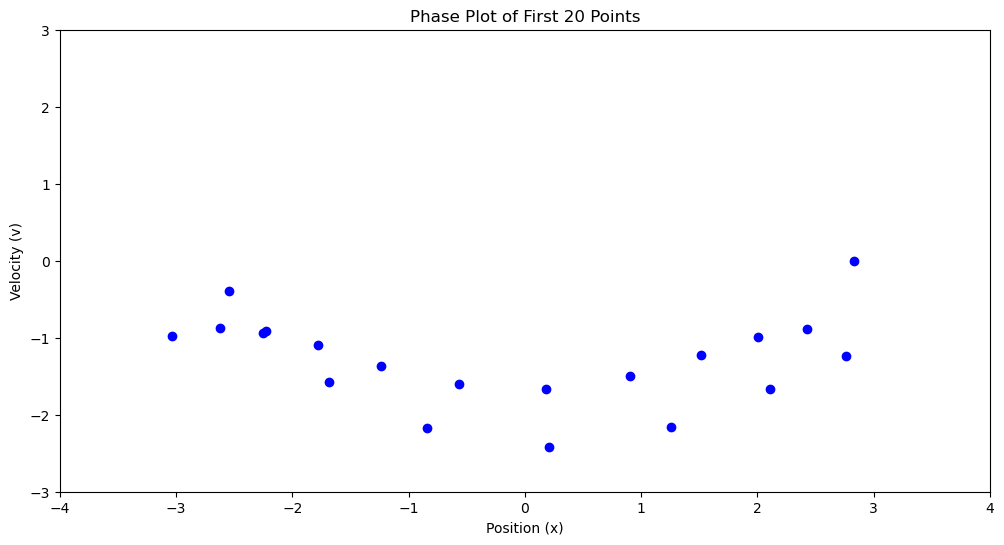

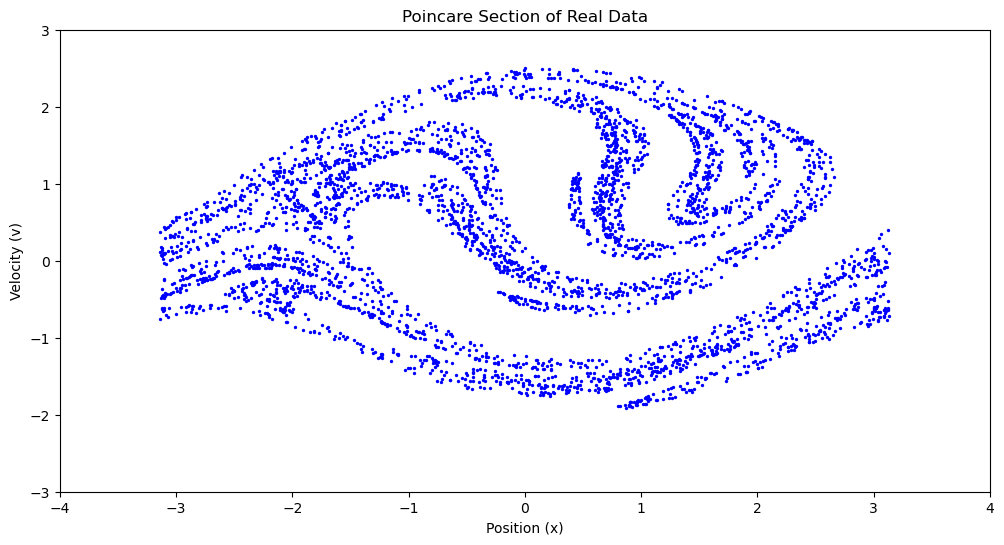

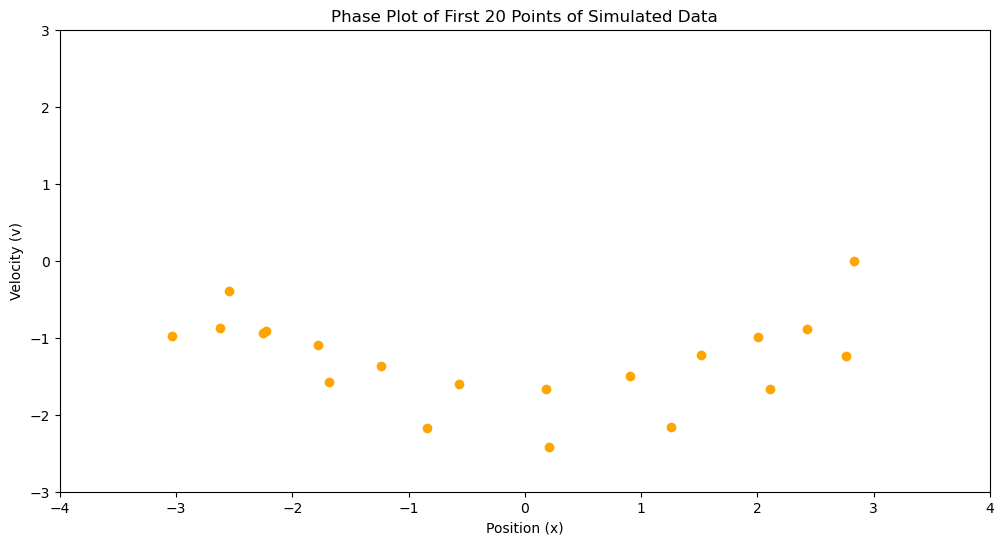

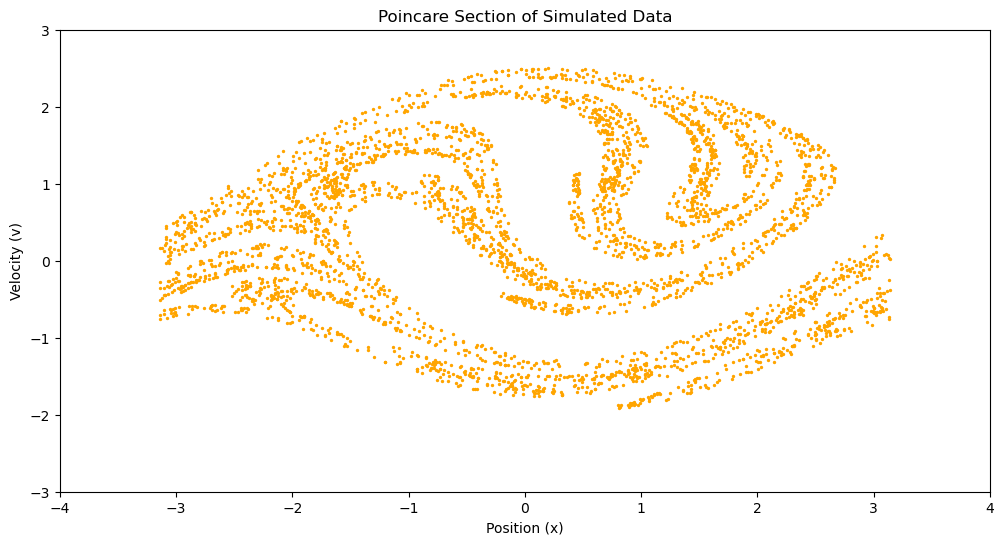

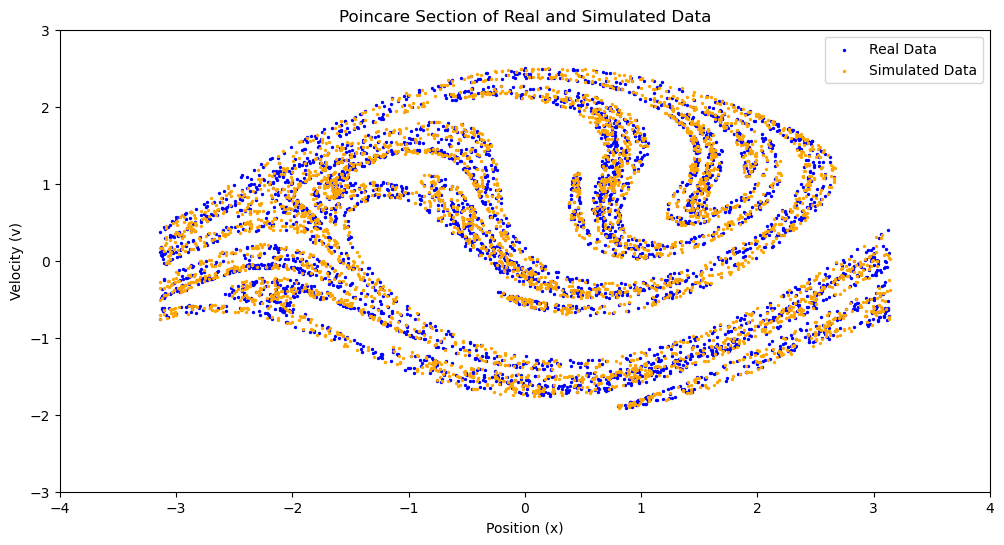

In [10]:
# process data to be wrapped in 2*pi for phase plots
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

x_real_wrapped = wrap_to_pi(real_data['x'].to_numpy())
x_sim_wrapped = wrap_to_pi(sim_data['x'].to_numpy())

# phase plot of everything showing its chaotic
plt.figure(figsize=(6, 3))
plt.plot(x_real_wrapped, real_data['v'], lw=1.2, alpha=0.9, label='Real')
plt.plot(x_sim_wrapped, sim_data['v'], lw=1.2, alpha=0.9, label='Simulated')
plt.xlabel('Wrapped position x (rad), modulo 2π')
plt.ylabel('Velocity v')
plt.title('Phase Plot with x Periodic in 2π')
plt.xlim(-np.pi, np.pi)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# plot first 20 rows of x and v against each other to check to see if im on the right track
x_real_wrapped_20 = wrap_to_pi(real_data['x'].iloc[:20].to_numpy())
v_real_20 = real_data['v'].iloc[:20].to_numpy()
plt.figure(figsize=(12, 6))
plt.scatter(x_real_wrapped_20, v_real_20, label='Real Data', color='blue')
plt.axis([-4, 4, -3, 3])  # Set axis limits for better visualization
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.title('Phase Plot of First 20 Points')
plt.show()

# poincare section of real data, using every 20th row since we were told that every drive period contains 20 data points 
x_real_wrapped_20 = wrap_to_pi(real_data['x'].iloc[::20].to_numpy())
v_real_20 = real_data['v'].iloc[::20].to_numpy()
plt.figure(figsize=(12, 6))
plt.scatter(x_real_wrapped_20, v_real_20, s=2, label='Real Data', color='blue')
plt.axis([-4, 4, -3, 3]) 
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.title('Poincare Section of Real Data')
plt.show()

# phase plot of first 20 rows of simulated data
x_sim_wrapped_20 = wrap_to_pi(sim_data['x'].iloc[:20].to_numpy())
v_sim_20 = sim_data['v'].iloc[:20].to_numpy()
plt.figure(figsize=(12, 6))
plt.scatter(x_sim_wrapped_20, v_sim_20, label='Simulated Data', color='orange')
plt.axis([-4, 4, -3, 3]) 
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.title('Phase Plot of First 20 Points of Simulated Data')
plt.show()

#poincare of simulated data
x_sim_wrapped_20 = wrap_to_pi(sim_data['x'].iloc[::20].to_numpy())
v_sim_20 = sim_data['v'].iloc[::20].to_numpy()
plt.figure(figsize=(12, 6))
plt.scatter(x_sim_wrapped_20, v_sim_20, s=2, label='Simulated Data', color='orange')
plt.axis([-4, 4, -3, 3])  # Set axis limits for better visualization
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.title('Poincare Section of Simulated Data')
plt.show()

#poincare overlaid, just for fun
x_real_wrapped_20 = wrap_to_pi(real_data['x'].iloc[::20].to_numpy())
v_real_20 = real_data['v'].iloc[::20].to_numpy()
x_sim_wrapped_20 = wrap_to_pi(sim_data['x'].iloc[::20].to_numpy())
v_sim_20 = sim_data['v'].iloc[::20].to_numpy()
plt.figure(figsize=(12, 6))
plt.scatter(x_real_wrapped_20, v_real_20, s=2, label='Real Data', color='blue')
plt.scatter(x_sim_wrapped_20, v_sim_20, s=2, label='Simulated Data', color='orange')
plt.axis([-4, 4, -3, 3])  # Set axis limits for better visualization
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.title('Poincare Section of Real and Simulated Data')
plt.legend()
plt.show()


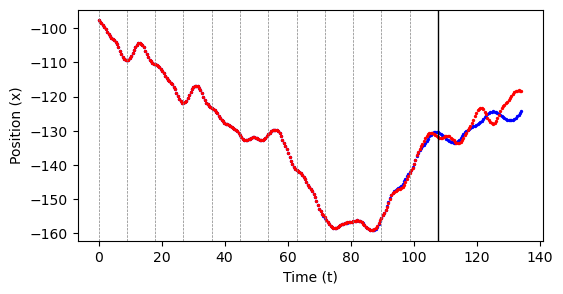

In [17]:
# plotting positon vs time again but including vertical lines at the drive periods
plt.figure(figsize=(6, 3))
plt.scatter(real_t, real_x, s=2, label='Real Data', color='blue')
plt.scatter(sim_t, sim_x, s=2, label='Simulated Data', color='red')
for i in range(0,12):
    plt.axvline(x=2*np.pi*i/0.7, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=2*np.pi*12/0.7, color='black', linestyle='-', linewidth=1, label='Additional Drive Period')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.show()